# 3.4.2 Data Understanding

# 1. Import Libraries
# 2. Load Raw Datasets
# 3. Dataset Structure Overview
# 4. Remove Unnecessary Columns
# 5. Extract 2022 Data (Wide Format)
# 6. 2022 Coverage Analysis
# 7. Merge 2022 Datasets (For Understanding)
# 8. Descriptive Statistics (2022)
# 9. Histogram Analysis (2022)
# 10. Boxplot Analysis (2022)
# 11. Correlation Analysis (2022)

# Predictive Modelling of Health Workforce Shortages Using Socio-Economic Determinants

## 3.4.2 Data Understanding – 2022 Cross-Sectional

In [1]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 2. Load Raw Datasets
# ==========================================

df_physicians = pd.read_csv("../data/physicians.csv", skiprows=4)
df_gdp = pd.read_csv("../data/GDP.csv", skiprows=4)
df_health = pd.read_csv("../data/health_expenditure.csv", skiprows=4)
df_population = pd.read_csv("../data/population_growth.csv", skiprows=4)
df_school = pd.read_csv("../data/school_enrollment.csv", skiprows=4)
df_unemployment = pd.read_csv("../data/unemployment.csv", skiprows=4)
df_urban = pd.read_csv("../data/urban_population.csv", skiprows=4)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
# ==========================================
# 3. Dataset Structure Overview
# ==========================================

datasets = {
    "physicians": df_physicians,
    "gdp": df_gdp,
    "health_expenditure": df_health,
    "population_growth": df_population,
    "school_enrollment": df_school,
    "unemployment": df_unemployment,
    "urban_population": df_urban
}

for name, df in datasets.items():
    print(f"\n===== {name.upper()} =====")
    print("Shape:", df.shape)


===== PHYSICIANS =====
Shape: (266, 70)

===== GDP =====
Shape: (266, 70)

===== HEALTH_EXPENDITURE =====
Shape: (266, 70)

===== POPULATION_GROWTH =====
Shape: (266, 70)

===== SCHOOL_ENROLLMENT =====
Shape: (266, 70)

===== UNEMPLOYMENT =====
Shape: (266, 70)

===== URBAN_POPULATION =====
Shape: (266, 70)


In [4]:
# ==========================================
# 4. Remove Unnecessary Columns
# ==========================================

for name, df in datasets.items():
    # Drop unnamed columns if they exist
    df.drop(columns=[col for col in df.columns if "Unnamed" in col], 
            inplace=True, 
            errors='ignore')

print("Unnecessary columns removed.")

Unnecessary columns removed.


In [5]:
# ==========================================
# 5. Extract 2022 Data (Still Wide Format)
# ==========================================

def extract_2022(df):
    return df[["Country Name", "Country Code", "2022"]].copy()

phys_2022 = extract_2022(df_physicians)
gdp_2022 = extract_2022(df_gdp)
health_2022 = extract_2022(df_health)
pop_2022 = extract_2022(df_population)
school_2022 = extract_2022(df_school)
unemp_2022 = extract_2022(df_unemployment)
urban_2022 = extract_2022(df_urban)

print("2022 columns extracted.")

2022 columns extracted.


In [6]:
# ==========================================
# 6. 2022 Coverage Analysis
# ==========================================

coverage = {
    "physicians": phys_2022["2022"].notnull().sum(),
    "gdp": gdp_2022["2022"].notnull().sum(),
    "health_expenditure": health_2022["2022"].notnull().sum(),
    "population_growth": pop_2022["2022"].notnull().sum(),
    "school_enrollment": school_2022["2022"].notnull().sum(),
    "unemployment": unemp_2022["2022"].notnull().sum(),
    "urban_population": urban_2022["2022"].notnull().sum()
}

coverage

{'physicians': np.int64(172),
 'gdp': np.int64(257),
 'health_expenditure': np.int64(240),
 'population_growth': np.int64(264),
 'school_enrollment': np.int64(161),
 'unemployment': np.int64(234),
 'urban_population': np.int64(265)}

In [7]:
# ==========================================
# 7. Merge 2022 Datasets (For Understanding)
# ==========================================

df_2022 = phys_2022.rename(columns={"2022": "physicians"}) \
    .merge(gdp_2022.rename(columns={"2022": "gdp"}), on=["Country Name", "Country Code"], how="left") \
    .merge(health_2022.rename(columns={"2022": "health_expenditure"}), on=["Country Name", "Country Code"], how="left") \
    .merge(pop_2022.rename(columns={"2022": "population_growth"}), on=["Country Name", "Country Code"], how="left") \
    .merge(school_2022.rename(columns={"2022": "school_enrollment"}), on=["Country Name", "Country Code"], how="left") \
    .merge(unemp_2022.rename(columns={"2022": "unemployment"}), on=["Country Name", "Country Code"], how="left") \
    .merge(urban_2022.rename(columns={"2022": "urban_population"}), on=["Country Name", "Country Code"], how="left")

df_2022.shape

(266, 9)

In [8]:
# ==========================================
# 8. Descriptive Statistics (2022)
# ==========================================

df_2022.describe()

,physicians,gdp,health_expenditure,population_growth,school_enrollment,unemployment,urban_population
count,172.000000,2.570000e+02,240.000000,264.000000,161.000000,234.000000,265.000000
mean,2.079558,3.295601e+12,6.747365,1.025077,53.505448,6.921026,61.240849
std,1.724159,1.113559e+13,3.268229,1.445411,29.327914,5.284437,22.164086
min,0.028000,5.906598e+07,1.770422,-7.619320,2.708137,0.130000,14.692307
25%,0.285183,1.242906e+10,4.386774,0.205076,30.942110,3.738000,43.155477
50%,1.927500,7.059411e+10,5.952799,0.957736,55.166531,5.417630,61.593524
75%,3.500500,6.469503e+11,8.470772,1.966609,76.915459,8.246497,79.113483
max,6.598000,1.022515e+14,23.088169,5.907018,166.665649,36.472000,100.000000


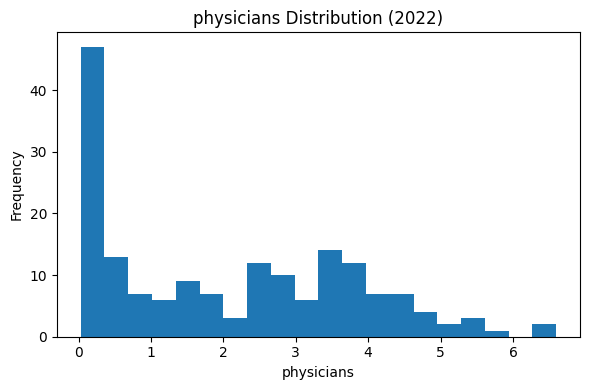

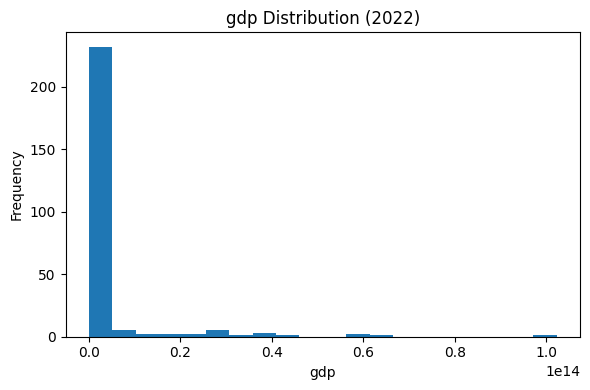

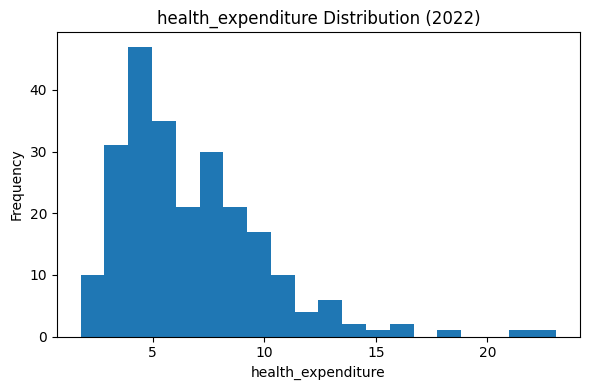

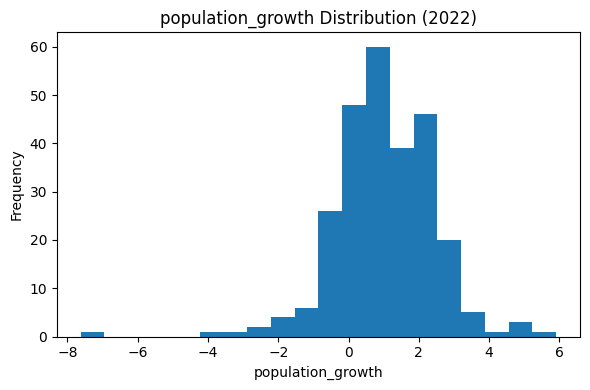

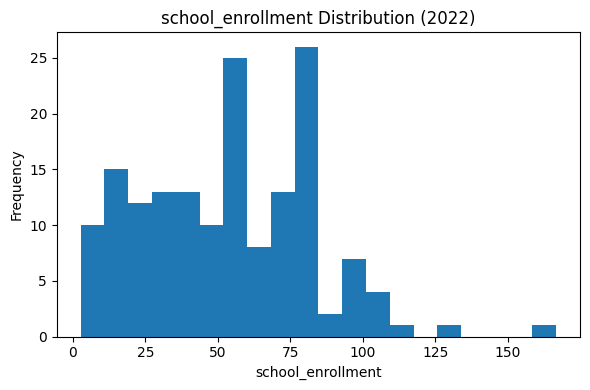

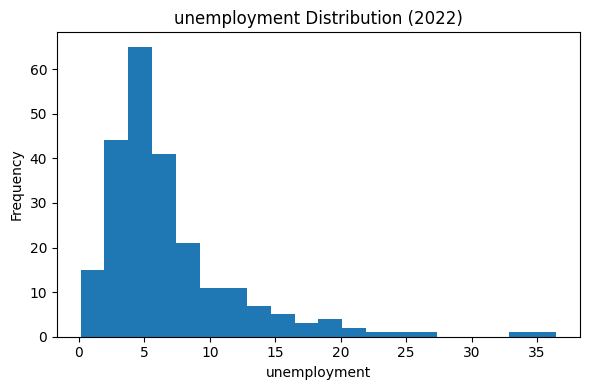

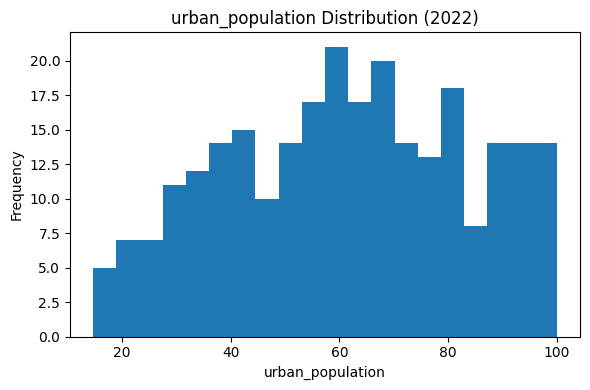

In [9]:
# ==========================================
# 9. Histogram Analysis (2022)
# ==========================================

for column in df_2022.columns:
    if column not in ["Country Name", "Country Code"]:
        
        plt.figure(figsize=(6,4))
        plt.hist(df_2022[column].dropna(), bins=20)
        plt.title(f"{column} Distribution (2022)")
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

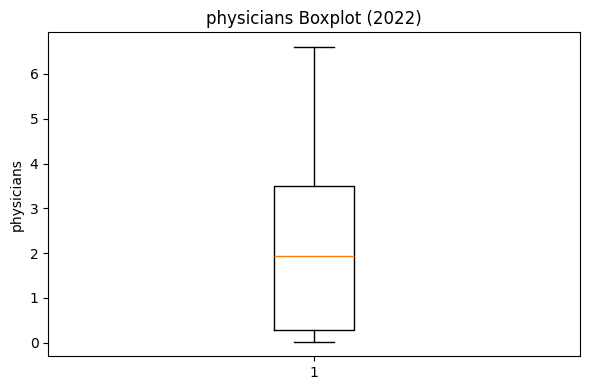

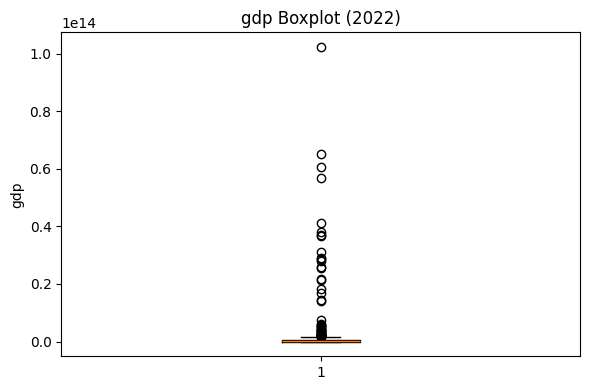

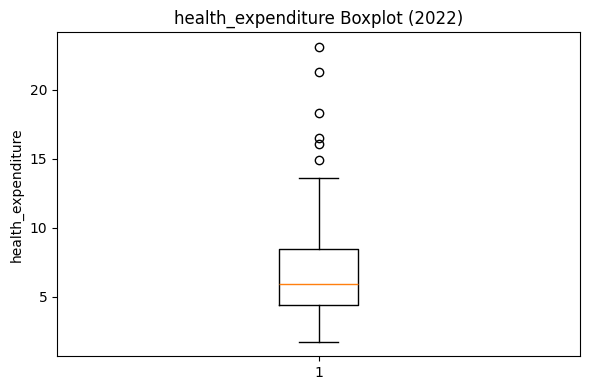

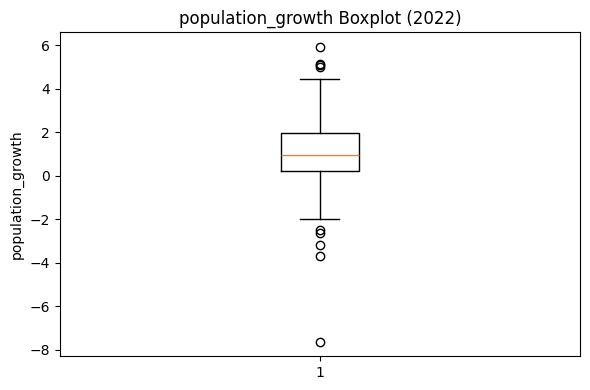

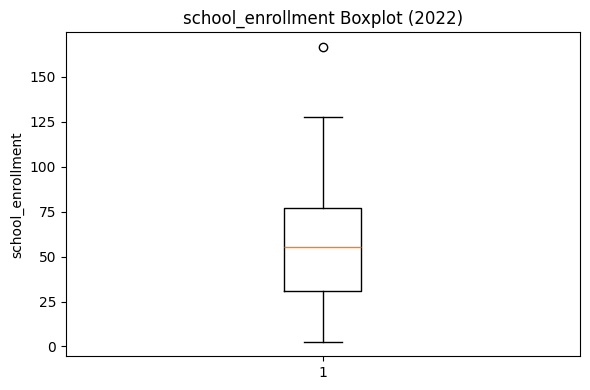

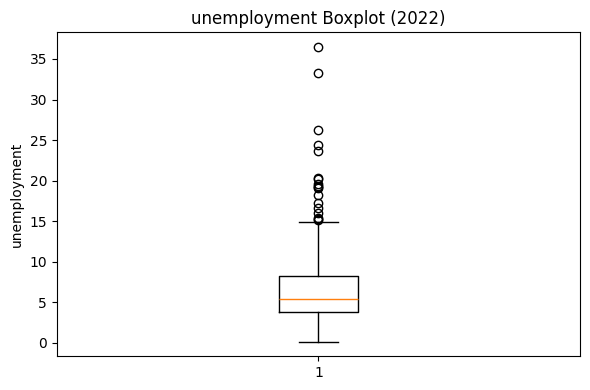

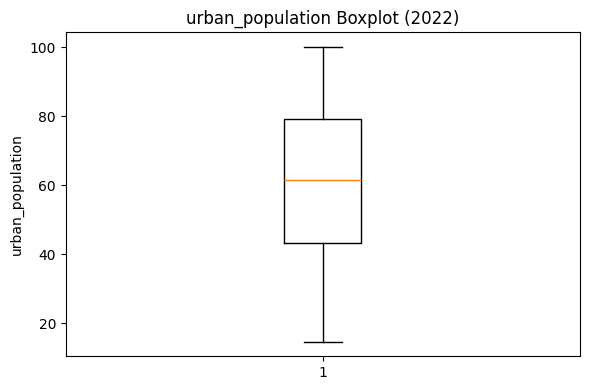

In [10]:
# ==========================================
# 10. Boxplot Analysis (2022)
# ==========================================

for column in df_2022.columns:
    if column not in ["Country Name", "Country Code"]:
        
        plt.figure(figsize=(6,4))
        plt.boxplot(df_2022[column].dropna())
        plt.title(f"{column} Boxplot (2022)")
        plt.ylabel(column)
        plt.tight_layout()
        plt.show()

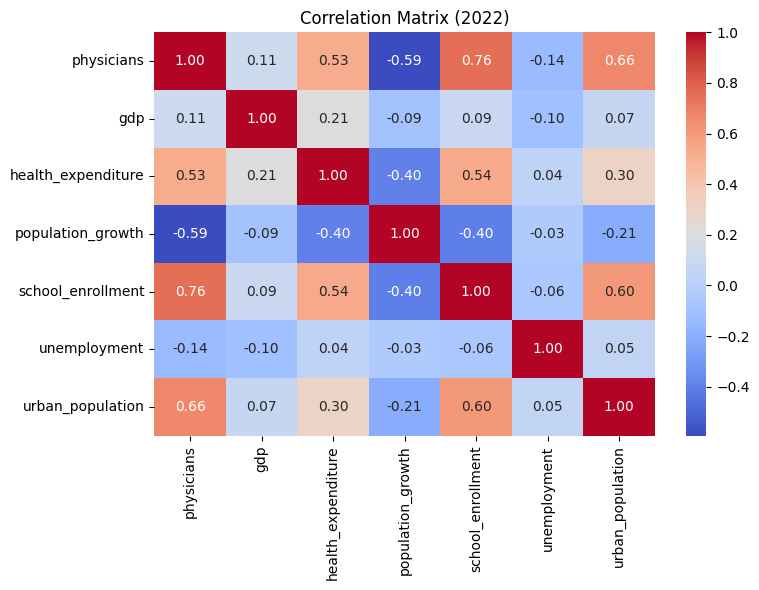

In [11]:
# ==========================================
# 11. Correlation Analysis (2022)
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Remove non-numeric columns
numeric_df = df_2022.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (2022)")
plt.tight_layout()
plt.show()

# 3.4.1 Data Pre-processing – 2022 Cross-Sectional

# 1. Dataset Construction (2022 Extraction)
# 2. Removal of Non-Country Aggregates
# 3. Missing Value Handling
# 3.1 Check Remaining Missing Values (Predictors)
# 3.2 Predictor Missing Value Imputation (Median)
# 4. Target Variable Definition (Workforce Shortage Classification)
# 5. Outlier Treatment Strategy
# 6. Data Transformation (Log Transformation)
# 6.1 Distribution Comparison (Histogram: GDP vs Log GDP)
# 6.2 Skewness Check (Before vs After Log)
# 7. Feature Selection
# 8. Feature Scaling (Standardization)
# 9. Final Dataset Verification
# 10. Final Model-Ready Dataset Preview

In [12]:
# ==================================================
# 3.4.1 Data Pre-processing – 2022 Cross-Sectional
# ==================================================

# 1. Dataset Construction (2022 Extraction)

year = "2022"

df_2022 = pd.DataFrame({
    "Country Name": df_physicians["Country Name"],
    "Country Code": df_physicians["Country Code"],
    "physicians": df_physicians[year],
    "gdp": df_gdp[year],
    "health_expenditure": df_health[year],
    "population_growth": df_population[year],
    "school_enrollment": df_school[year],
    "unemployment": df_unemployment[year],
    "urban_population": df_urban[year]
})

print("Initial Dataset Shape:", df_2022.shape)

Initial Dataset Shape: (266, 9)


In [13]:
# ------------------------------------------
# 2. Removal of Non-Country Aggregates
# ------------------------------------------

import pycountry

# Create set of valid ISO 3-letter country codes
valid_iso3 = {country.alpha_3 for country in pycountry.countries}

# Keep only real countries
df_2022 = df_2022[df_2022["Country Code"].isin(valid_iso3)]

print("After Removing Aggregates:", df_2022.shape)

After Removing Aggregates: (215, 9)


In [14]:
# ------------------------------------------
# 3. Missing Value Handling (Target Variable)
# ------------------------------------------

before = df_2022.shape[0]

df_2022 = df_2022.dropna(subset=["physicians"])

after = df_2022.shape[0]

print("Rows removed due to missing physicians:", before - after)
print("Remaining countries:", after)

Rows removed due to missing physicians: 90
Remaining countries: 125


In [15]:
# ------------------------------------------
# 3.1 Check Remaining Missing Values (Predictors)
# ------------------------------------------

df_2022.isnull().sum()

Country Name           0
Country Code           0
physicians             0
gdp                    3
health_expenditure     0
population_growth      1
school_enrollment     40
unemployment           4
urban_population       0
dtype: int64

In [16]:
# ------------------------------------------
# 3.2 Predictor Missing Value Imputation (Median)
# ------------------------------------------

print("Missing Before Imputation:\n")
print(df_2022.isnull().sum())

predictor_columns = [
    "gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]

for col in predictor_columns:
    median_value = df_2022[col].median()
    df_2022[col] = df_2022[col].fillna(median_value)

print("\nMissing After Imputation:\n")
print(df_2022.isnull().sum())

Missing Before Imputation:

Country Name           0
Country Code           0
physicians             0
gdp                    3
health_expenditure     0
population_growth      1
school_enrollment     40
unemployment           4
urban_population       0
dtype: int64

Missing After Imputation:

Country Name          0
Country Code          0
physicians            0
gdp                   0
health_expenditure    0
population_growth     0
school_enrollment     0
unemployment          0
urban_population      0
dtype: int64


In [17]:
# ------------------------------------------
# 4. Target Variable Definition (Bottom 30%)
# ------------------------------------------

threshold = df_2022["physicians"].quantile(0.30)

df_2022["shortage"] = (df_2022["physicians"] <= threshold).astype(int)

print("30th Percentile Threshold:", threshold)
print("\nClass Distribution:")
print(df_2022["shortage"].value_counts())
print("\nClass Percentage:")
print(df_2022["shortage"].value_counts(normalize=True) * 100)

30th Percentile Threshold: 0.32539999999999997

Class Distribution:
shortage
0    87
1    38
Name: count, dtype: int64

Class Percentage:
shortage
0    69.6
1    30.4
Name: proportion, dtype: float64


In [18]:
# ------------------------------------------
# 5. Outlier Treatment Strategy
# ------------------------------------------

# Based on boxplot analysis in Data Understanding, extreme values were observed particularly in GDP and unemployment.

# However, these values represent structural economic disparities between countries rather than data entry errors.

# Therefore, no observations were removed.

print("Outlier strategy: No removal. Structural disparities retained.")

Outlier strategy: No removal. Structural disparities retained.


In [19]:
# ------------------------------------------
# 6. Log Transformation (GDP)
# ------------------------------------------

df_2022["log_gdp"] = np.log1p(df_2022["gdp"])

print("Log transformation applied to GDP.")

Log transformation applied to GDP.


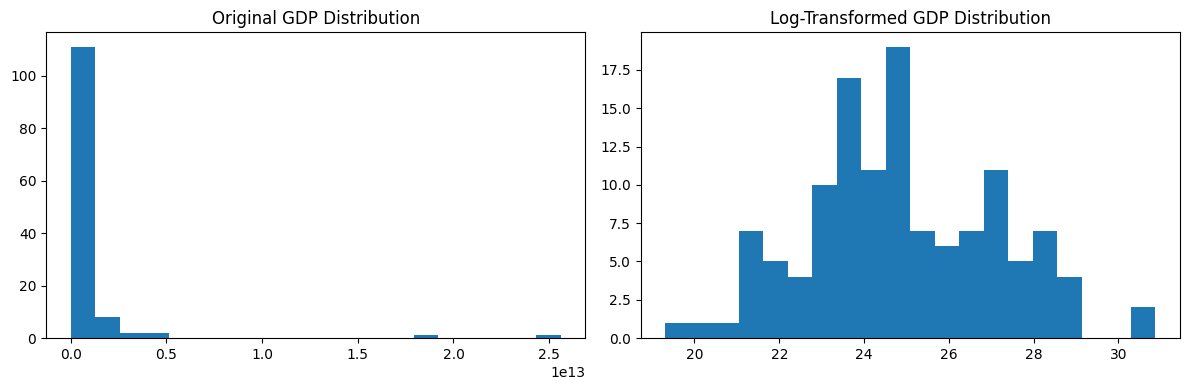

In [20]:
# ------------------------------------------
# 6.1 Distribution Comparison (Histogram: GDP vs Log GDP)
# ------------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df_2022["gdp"], bins=20)
plt.title("Original GDP Distribution")

plt.subplot(1,2,2)
plt.hist(df_2022["log_gdp"], bins=20)
plt.title("Log-Transformed GDP Distribution")

plt.tight_layout()
plt.show()

In [21]:
# ------------------------------------------
# 6.2 Skewness Check (Before vs After Log)
# ------------------------------------------

from scipy.stats import skew

original_skew = skew(df_2022["gdp"])
log_skew = skew(df_2022["log_gdp"])

print("Original GDP Skewness:", round(original_skew, 3))
print("Log GDP Skewness:", round(log_skew, 3))

Original GDP Skewness: 7.234
Log GDP Skewness: 0.178


In [22]:
# ------------------------------------------
# 7. Feature Selection
# ------------------------------------------

# Target variable: shortage
target = "shortage"

# Selected predictors (excluding original physicians variable)
features = [
    "log_gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]

print("Selected Features:")
print(features)

Selected Features:
['log_gdp', 'health_expenditure', 'population_growth', 'school_enrollment', 'unemployment', 'urban_population']


In [23]:
# ------------------------------------------
# 8. Feature Scaling (Standardization)
# ------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_2022.copy()

df_scaled[features] = scaler.fit_transform(df_2022[features])

print("Feature scaling completed.")
print(df_scaled[features].describe().round(2))

Feature scaling completed.
       log_gdp  health_expenditure  population_growth  school_enrollment  \
count   125.00              125.00             125.00             125.00   
mean      0.00                0.00               0.00               0.00   
std       1.00                1.00               1.00               1.00   
min      -2.54               -1.63              -2.92              -2.19   
25%      -0.66               -0.85              -0.69              -0.20   
50%      -0.02               -0.05               0.04              -0.03   
75%       0.69                0.68               0.74               0.58   
max       2.70                3.27               2.81               4.20   

       unemployment  urban_population  
count        125.00            125.00  
mean          -0.00              0.00  
std            1.00              1.00  
min           -1.11             -2.13  
25%           -0.60             -0.83  
50%           -0.31              0.11  
75%     

In [24]:
# ------------------------------------------
# 9. Final Dataset Verification
# ------------------------------------------

print("Final Dataset Shape:", df_scaled.shape)

print("\nMissing Values Check:")
print(df_scaled.isnull().sum())

print("\nClass Distribution:")
print(df_scaled["shortage"].value_counts())

print("\nClass Percentage:")
print(df_scaled["shortage"].value_counts(normalize=True) * 100)

Final Dataset Shape: (125, 11)

Missing Values Check:
Country Name          0
Country Code          0
physicians            0
gdp                   0
health_expenditure    0
population_growth     0
school_enrollment     0
unemployment          0
urban_population      0
shortage              0
log_gdp               0
dtype: int64

Class Distribution:
shortage
0    87
1    38
Name: count, dtype: int64

Class Percentage:
shortage
0    69.6
1    30.4
Name: proportion, dtype: float64


In [25]:
# ------------------------------------------
# 10. Final Model-Ready Dataset Preview
# ------------------------------------------

df_scaled.sample(20, random_state=42)

,Country Name,Country Code,physicians,gdp,health_expenditure,population_growth,school_enrollment,unemployment,urban_population,shortage,log_gdp
34,Central African Republic,CAF,0.029,2.382619e+09,1.049190,-1.180743,-0.025426,-0.143421,-0.872200,1,-1.507819
81,United Kingdom,GBR,3.143,3.181244e+12,1.435955,-0.291357,0.811350,-0.558369,1.015295,0,1.753048
69,Eritrea,ERI,0.088,6.335451e+10,-0.999377,0.327080,-0.025426,-0.185262,-1.271904,1,-0.021411
162,Montenegro,MNE,2.808,6.251215e+09,1.130425,-1.150082,-0.056865,1.267304,0.177114,0,-1.070772
106,Indonesia,IDN,0.681,1.319101e+12,-1.397816,-0.421622,-0.645159,-0.608776,-0.197909,0,1.354176
186,Peru,PER,1.649,2.460656e+11,-0.250008,-0.263230,-0.025426,-0.472217,1.076518,0,0.593376
114,Iceland,ISL,4.440,2.916610e+10,0.756306,0.892072,1.016207,-0.554910,1.541861,0,-0.372896
264,Zambia,ZMB,0.324,2.916378e+10,-0.549148,1.077769,-0.025426,-0.191851,-0.809426,1,-0.372932
190,Poland,POL,3.424,6.956075e+11,-0.125656,-1.297893,0.638668,-0.716013,-0.087027,0,1.064230
10,Armenia,ARM,3.360,1.951351e+10,1.053297,-0.803154,-0.066599,1.036686,0.184757,0,-0.554996
